In [16]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

order = ['Fed-Fed', 'Fed-Starved', 'Starved-Starved']
palette = {
    "Fed-Fed": "#4C72B0",
    "Fed-Starved": "#55A868",
    "Starved-Starved": "#C44E52",
}
housing_order = ['GH', 'SI']


df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-fed/included_files.csv')
df1['Housing'] = 'GH'
df1['Condition'] = 'Fed-Fed'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-starved/included_files.csv')
df2['Housing'] = 'GH'
df2['Condition'] = 'Fed-Starved'

df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/starved-starved/included_files.csv')
df3['Housing'] = 'GH'
df3['Condition'] = 'Starved-Starved'


df4 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-fed/included_files.csv')
df4['Housing'] = 'SI'
df4['Condition'] = 'Fed-Fed'

df5 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-starved/included_files.csv')
df5['Housing'] = 'SI'
df5['Condition'] = 'Fed-Starved'

df6 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/starved-starved/included_files.csv')
df6['Housing'] = 'SI'
df6['Condition'] = 'Starved-Starved'


df = pd.concat([df1, df2, df3, df4, df5, df6], ignore_index=True)


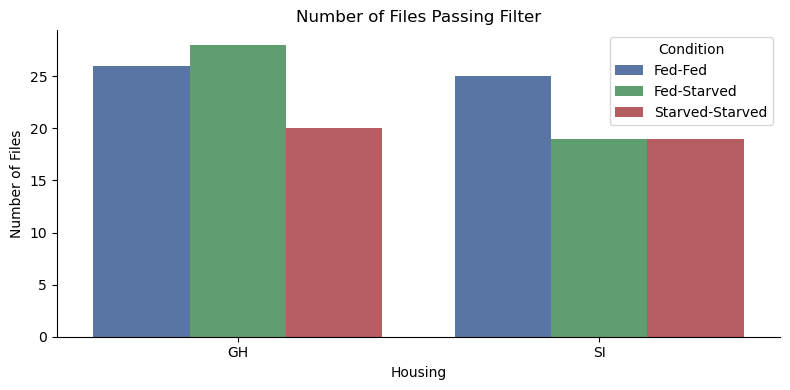

In [17]:
# Also include counts
counts = (
    df.groupby(["Housing", "Condition"])["passed_filter"]
      .agg(
          Total="count",
          Passed=lambda x: (x == "Y").sum(),
          Failed=lambda x: (x == "N").sum()
      )
      .reset_index()
)


plt.figure(figsize=(8,4))
sns.barplot(
    x="Housing", y="Passed", hue="Condition", data=counts,
    order=housing_order, hue_order=order, palette=palette
)
plt.title("Number of Files Passing Filter")
plt.ylabel("Number of Files")
plt.xlabel("Housing")
plt.legend(title="Condition")
plt.tight_layout()
sns.despine()

plt.show()


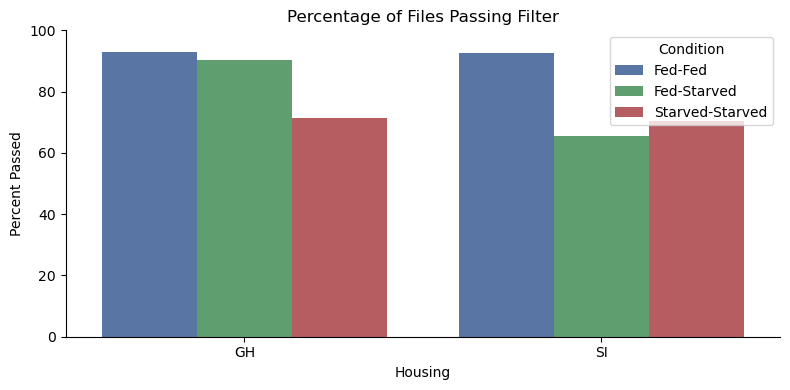

In [18]:
# Percentage of files passing the filter for each condition
summary = (
    df.groupby(["Housing", "Condition"])["passed_filter"]
      .apply(lambda x: (x == "Y").mean() * 100)
      .reset_index(name="Percent Passed")
)

plt.figure(figsize=(8,4))
sns.barplot(
    x="Housing", y="Percent Passed", hue="Condition", data=summary,
    order=housing_order, hue_order=order, palette=palette
)
plt.title("Percentage of Files Passing Filter")
plt.ylabel("Percent Passed")
plt.ylim(0, 100)
plt.xlabel("Housing")
plt.legend(title="Condition")
plt.tight_layout()
sns.despine()

plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/percentage_files_passing_filter.pdf', format='pdf')
plt.show()


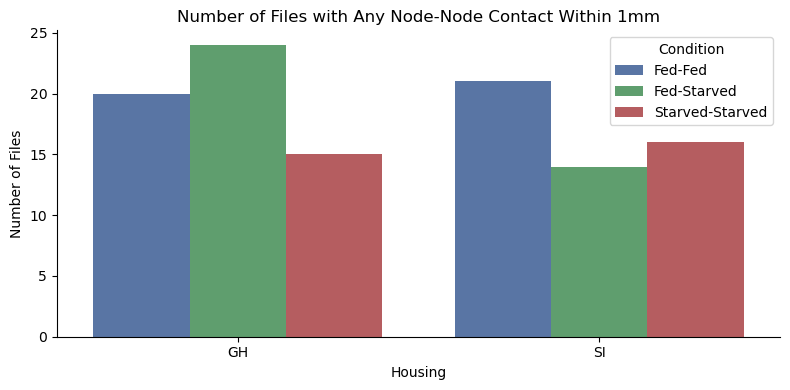

In [19]:
counts = (
    df.groupby(["Housing", "Condition"])["any_node_node_contact_within_1mm"]
      .agg(
          Total="count",
          Passed=lambda x: (x == "Y").sum(),
          Failed=lambda x: (x == "N").sum()
      )
      .reset_index()
)

plt.figure(figsize=(8,4))
sns.barplot(
    x="Housing", y="Passed", hue="Condition", data=counts,
    order=housing_order, hue_order=order, palette=palette
)
plt.title("Number of Files with Any Node-Node Contact Within 1mm")
plt.ylabel("Number of Files")
plt.xlabel("Housing")
plt.legend(title="Condition")
plt.tight_layout()
sns.despine()
plt.show()


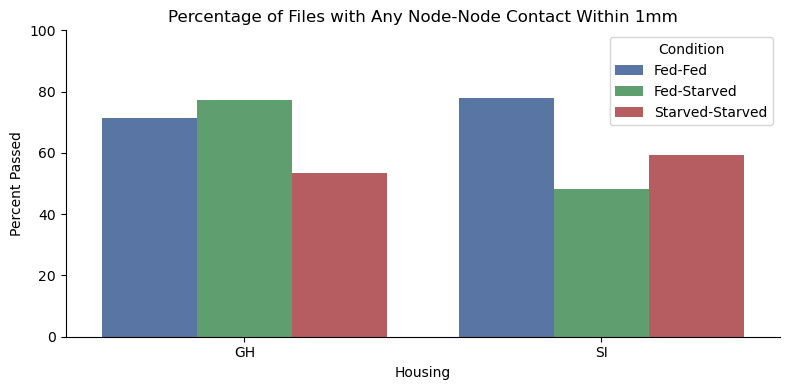

In [20]:
# Percentage of files passing the filter for each condition
summary = (
    df.groupby(["Housing", "Condition"])["any_node_node_contact_within_1mm"]
      .apply(lambda x: (x == "Y").mean() * 100)
      .reset_index(name="Percent Passed")
)

plt.figure(figsize=(8,4))
sns.barplot(
    x="Housing", y="Percent Passed", hue="Condition", data=summary,
    order=housing_order, hue_order=order, palette=palette
)
plt.title("Percentage of Files with Any Node-Node Contact Within 1mm")
plt.ylabel("Percent Passed")
plt.ylim(0, 100)
plt.xlabel("Housing")
plt.legend(title="Condition")
plt.tight_layout()
sns.despine()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/percentage_files_passing_filter_1mm.pdf', format='pdf')
plt.show()


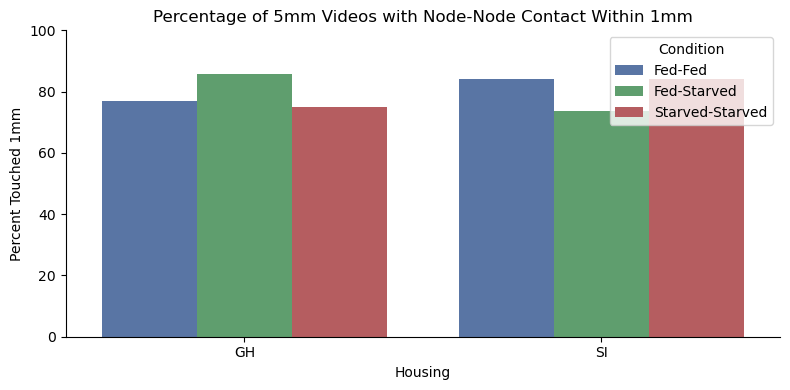

In [ ]:
# Of videos where heads came within 5mm, calculate the percentage with node-node contact within 1mm
within_5mm = df[df["head_to_any_node_within_5mm"] == "Y"]

summary = (
    within_5mm.groupby(["Housing", "Condition"])["any_node_node_contact_within_1mm"]
      .apply(lambda x: (x == "Y").mean() * 100)
      .reset_index(name="Percent Touched 1mm")
)

plt.figure(figsize=(8,4))
sns.barplot(
    x="Housing", y="Percent Touched 1mm", hue="Condition", data=summary,
    order=housing_order, hue_order=order, palette=palette
)
plt.title("Percentage of 5mm Videos with Node-Node Contact Within 1mm")
plt.ylabel("Percent Touched 1mm")
plt.ylim(0, 100)
plt.xlabel("Housing")
plt.legend(title="Condition")
plt.tight_layout()
sns.despine()
plt.show()
